# 04 - No-RAG Baseline

Questo notebook mostra la modalità adottata per lo step 04: valutare le domande pulite senza retrieval, senza Qdrant e senza contesto legale aggiunto.

La run simulata è sempre eseguibile e serve a verificare forma degli artifact, metriche e grafici. Le metriche scientifiche devono invece essere prodotte da una run reale Utopia.

In [1]:
from pathlib import Path
from typing import Any
import json
import os
import sys
import tempfile

os.environ.setdefault("MPLBACKEND", "Agg")
os.environ.setdefault("MPLCONFIGDIR", tempfile.mkdtemp(prefix="mpl-cache-"))

import matplotlib.pyplot as plt

try:
    from IPython.display import display
except ImportError:
    display = None

ROOT = Path.cwd().resolve()
while not (ROOT / "pyproject.toml").exists():
    if ROOT.parent == ROOT:
        raise RuntimeError("Project root not found")
    ROOT = ROOT.parent

SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from legal_rag.no_rag_baseline import NoRagConfig, run_no_rag_baseline
from legal_rag.oracle_context_evaluation.io import write_json, write_jsonl


def show_plot(fig) -> None:
    if display is not None:
        display(fig)
    else:
        fig.savefig(Path(tempfile.gettempdir()) / "no_rag_baseline_plot.png")
    plt.close(fig)

Matplotlib is building the font cache; this may take a moment.


## Demo simulata

Il client fake usa lo stesso contratto del client strutturato reale: riceve un prompt, un modello, uno schema JSON e restituisce un payload già strutturato. In questo modo si testano orchestrazione, scoring, manifest e report senza credenziali.

In [2]:
class FakeStructuredClient:
    def __init__(self) -> None:
        self.calls = {"mcq": 0, "no_hint": 0, "judge": 0}

    def structured_chat(
        self,
        *,
        prompt: str,
        model: str,
        payload_schema: dict[str, Any],
        timeout_seconds: int,
    ) -> dict[str, Any]:
        properties = payload_schema.get("properties", {})
        if "answer_label" in properties:
            self.calls["mcq"] += 1
            label = "A"
            if "Seconda domanda" in prompt:
                label = "A"
            if "Terza domanda" in prompt:
                label = "C"
            return {"structured": {"answer_label": label, "short_rationale": "demo"}}
        if "answer_text" in properties:
            self.calls["no_hint"] += 1
            return {"structured": {"answer_text": "Risposta dimostrativa senza contesto.", "short_rationale": "demo"}}
        if "score" in properties:
            self.calls["judge"] += 1
            score = 2
            if "Seconda domanda" in prompt:
                score = 1
            if "Terza domanda" in prompt:
                score = 0
            return {"structured": {"score": score, "explanation": "Giudizio simulato per mostrare la metrica."}}
        raise AssertionError(f"Unexpected schema: {payload_schema}")

In [3]:
demo_root = Path(tempfile.mkdtemp(prefix="no-rag-demo-"))
evaluation_dir = demo_root / "evaluation_clean"
output_dir = demo_root / "no_rag"
evaluation_dir.mkdir()

mcq_records = [
    {
        "qid": "eval-0001",
        "source_position": 1,
        "level": "L1",
        "question_stem": "Prima domanda?",
        "options": {"A": "Corretta", "B": "Errata", "C": "Errata", "D": "Errata", "E": "Errata", "F": "Errata"},
        "correct_label": "A",
        "correct_answer": "Corretta",
        "expected_references": ["Legge A - Art. 1"],
    },
    {
        "qid": "eval-0002",
        "source_position": 2,
        "level": "L2",
        "question_stem": "Seconda domanda?",
        "options": {"A": "Errata", "B": "Corretta", "C": "Errata", "D": "Errata", "E": "Errata", "F": "Errata"},
        "correct_label": "B",
        "correct_answer": "Corretta",
        "expected_references": ["Legge B - Art. 2"],
    },
    {
        "qid": "eval-0003",
        "source_position": 3,
        "level": "L3",
        "question_stem": "Terza domanda?",
        "options": {"A": "Errata", "B": "Errata", "C": "Corretta", "D": "Errata", "E": "Errata", "F": "Errata"},
        "correct_label": "C",
        "correct_answer": "Corretta",
        "expected_references": ["Legge C - Art. 3"],
    },
]
no_hint_records = [
    {
        "qid": record["qid"],
        "source_position": record["source_position"],
        "level": record["level"],
        "question": record["question_stem"],
        "correct_answer": record["correct_answer"],
        "expected_references": record["expected_references"],
        "linked_mcq_qid": record["qid"],
    }
    for record in mcq_records
]

write_jsonl(evaluation_dir / "questions_mcq.jsonl", mcq_records)
write_jsonl(evaluation_dir / "questions_no_hint.jsonl", no_hint_records)
write_json(evaluation_dir / "evaluation_manifest.json", {"schema_version": "evaluation-dataset-v1"})

fake_client = FakeStructuredClient()
manifest = run_no_rag_baseline(
    NoRagConfig(
        evaluation_dir=str(evaluation_dir),
        output_dir=str(output_dir),
        chat_model="fake-answer",
        judge_model="fake-judge",
        max_concurrency=2,
        random_seed=7,
    ),
    client=fake_client,
)

print(output_dir)
print(fake_client.calls)
manifest["counts"]

/var/folders/9b/g7kf969n2kl03xm30zpvmkm40000gp/T/no-rag-demo-9g81u04m/no_rag
{'mcq': 3, 'no_hint': 3, 'judge': 3}


{'mcq': 3, 'no_hint': 3, 'mcq_errors': 0, 'no_hint_errors': 0}

## Artifact prodotti

La pipeline esporta gli stessi file attesi da una run reale. Questo controllo è utile prima di confrontare i risultati con gli step RAG successivi.

In [4]:
artifacts = sorted(path.name for path in output_dir.iterdir())
artifacts

['mcq_results.jsonl',
 'no_hint_results.jsonl',
 'no_rag_manifest.json',
 'no_rag_summary.json',
 'quality_report.md']

In [5]:
def read_jsonl(path: Path) -> list[dict[str, Any]]:
    return [json.loads(line) for line in path.read_text(encoding="utf-8").splitlines() if line.strip()]

summary = json.loads((output_dir / "no_rag_summary.json").read_text(encoding="utf-8"))
mcq_rows = read_jsonl(output_dir / "mcq_results.jsonl")
no_hint_rows = read_jsonl(output_dir / "no_hint_results.jsonl")

summary

{'mcq': {'accuracy': 0.6666666666666666,
  'by_level': {'L1': {'accuracy': 1.0,
    'coverage': 1.0,
    'errors': 0,
    'judged': 1,
    'max_score_sum': 1,
    'mean_score': 1.0,
    'processed': 1,
    'score_sum': 1,
    'strict_accuracy': 1.0},
   'L2': {'accuracy': 0.0,
    'coverage': 1.0,
    'errors': 0,
    'judged': 1,
    'max_score_sum': 1,
    'mean_score': 0.0,
    'processed': 1,
    'score_sum': 0,
    'strict_accuracy': 0.0},
   'L3': {'accuracy': 1.0,
    'coverage': 1.0,
    'errors': 0,
    'judged': 1,
    'max_score_sum': 1,
    'mean_score': 1.0,
    'processed': 1,
    'score_sum': 1,
    'strict_accuracy': 1.0}},
  'coverage': 1.0,
  'dataset': 'mcq',
  'errors': 0,
  'judged': 3,
  'max_score_sum': 3,
  'mean_score': 0.6666666666666666,
  'processed': 3,
  'score_sum': 2,
  'strict_accuracy': 0.6666666666666666},
 'no_hint': {'accuracy': 0.5,
  'by_level': {'L1': {'accuracy': 1.0,
    'coverage': 1.0,
    'errors': 0,
    'judged': 1,
    'max_score_sum': 2,

In [6]:
mcq_rows[:2], no_hint_rows[:2]

([{'correct_label': 'A',
   'error': None,
   'level': 'L1',
   'options': {'A': 'Corretta',
    'B': 'Errata',
    'C': 'Errata',
    'D': 'Errata',
    'E': 'Errata',
    'F': 'Errata'},
   'predicted_label': 'A',
   'qid': 'eval-0001',
   'question': 'Prima domanda?',
   'score': 1},
  {'correct_label': 'B',
   'error': None,
   'level': 'L2',
   'options': {'A': 'Errata',
    'B': 'Corretta',
    'C': 'Errata',
    'D': 'Errata',
    'E': 'Errata',
    'F': 'Errata'},
   'predicted_label': 'A',
   'qid': 'eval-0002',
   'question': 'Seconda domanda?',
   'score': 0}],
 [{'correct_answer': 'Corretta',
   'error': None,
   'judge_explanation': 'Giudizio simulato per mostrare la metrica.',
   'judge_score': 2,
   'level': 'L1',
   'predicted_answer': 'Risposta dimostrativa senza contesto.',
   'qid': 'eval-0001',
   'question': 'Prima domanda?'},
  {'correct_answer': 'Corretta',
   'error': None,
   'judge_explanation': 'Giudizio simulato per mostrare la metrica.',
   'judge_score': 1

## Metriche globali

Le chiavi metriche sono identiche a quelle usate dallo step oracle-context: questo rende il baseline confrontabile con simple RAG e advanced RAG.

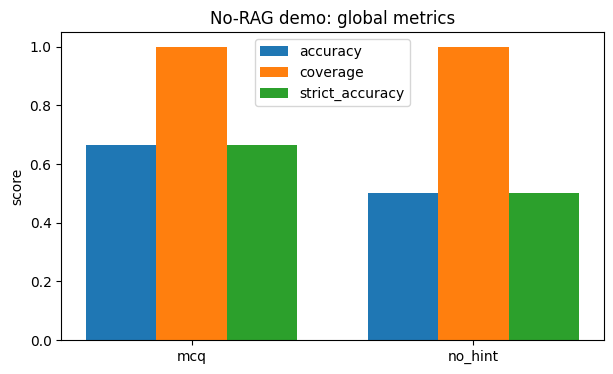

In [7]:
metric_names = ["accuracy", "coverage", "strict_accuracy"]
datasets = ["mcq", "no_hint"]

fig, ax = plt.subplots(figsize=(7, 4))
width = 0.25
x = range(len(datasets))

for offset, metric in enumerate(metric_names):
    values = [summary[name][metric] or 0 for name in datasets]
    ax.bar([idx + (offset - 1) * width for idx in x], values, width=width, label=metric)

ax.set_xticks(list(x), datasets)
ax.set_ylim(0, 1.05)
ax.set_ylabel("score")
ax.set_title("No-RAG demo: global metrics")
ax.legend()
show_plot(fig)

## Metriche per livello

Il raggruppamento `by_level` permette di capire se il baseline fallisce soprattutto sulle domande più difficili o se gli errori sono distribuiti uniformemente.

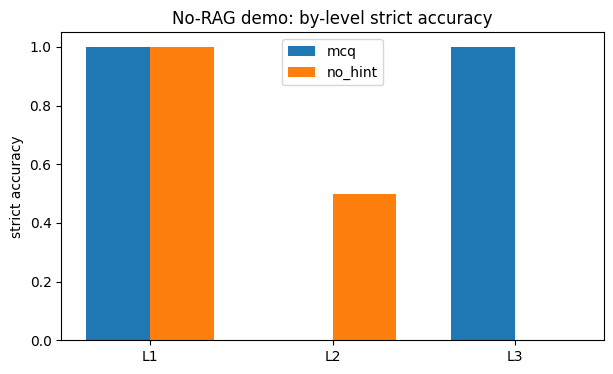

In [8]:
levels = sorted(set(summary["mcq"]["by_level"]) | set(summary["no_hint"]["by_level"]))
fig, ax = plt.subplots(figsize=(7, 4))
width = 0.35
x = range(len(levels))

mcq_values = [summary["mcq"]["by_level"].get(level, {}).get("strict_accuracy") or 0 for level in levels]
no_hint_values = [summary["no_hint"]["by_level"].get(level, {}).get("strict_accuracy") or 0 for level in levels]

ax.bar([idx - width / 2 for idx in x], mcq_values, width=width, label="mcq")
ax.bar([idx + width / 2 for idx in x], no_hint_values, width=width, label="no_hint")
ax.set_xticks(list(x), levels)
ax.set_ylim(0, 1.05)
ax.set_ylabel("strict accuracy")
ax.set_title("No-RAG demo: by-level strict accuracy")
ax.legend()
show_plot(fig)

## Run reale opzionale

Impostare `RUN_REAL_SMOKE=True` per eseguire una sola domanda contro Utopia. Impostare `RUN_FULL_BASELINE=True` solo quando si vuole produrre il baseline completo in `data/baseline_runs/no_rag/`.

In [12]:
RUN_REAL_SMOKE = False
RUN_FULL_BASELINE = True

if RUN_REAL_SMOKE:
    smoke_manifest = run_no_rag_baseline(
        NoRagConfig(
            evaluation_dir=str(ROOT / "data" / "evaluation_clean"),
            output_dir=str(ROOT / "data" / "baseline_runs" / "no_rag_smoke"),
            smoke=True,
        )
    )
    print(smoke_manifest["counts"])

if RUN_FULL_BASELINE:
    full_manifest = run_no_rag_baseline(
        NoRagConfig(
            evaluation_dir=str(ROOT / "data" / "evaluation_clean"),
            output_dir=str(ROOT / "data" / "baseline_runs" / "no_rag"),
            max_concurrency=4,
        )
    )
    print(full_manifest["counts"])

{'mcq': 100, 'no_hint': 100, 'mcq_errors': 0, 'no_hint_errors': 0}


## Resoconto performance reale

Questa cella legge gli artifact della run reale. Se esiste il full benchmark usa `data/baseline_runs/no_rag/`; altrimenti usa lo smoke run in `data/baseline_runs/no_rag_smoke/`.

In [13]:
def print_metric_block(name: str, metrics: dict[str, Any]) -> None:
    print(f"[{name}]")
    print(f"  processed       : {metrics['processed']}")
    print(f"  judged          : {metrics['judged']}")
    print(f"  errors          : {metrics['errors']}")
    print(f"  score_sum       : {metrics['score_sum']} / {metrics['max_score_sum']}")
    print(f"  accuracy        : {metrics['accuracy']}")
    print(f"  mean_score      : {metrics['mean_score']}")
    print(f"  coverage        : {metrics['coverage']}")
    print(f"  strict_accuracy : {metrics['strict_accuracy']}")
    print("  by_level:")
    for level, level_metrics in metrics["by_level"].items():
        print(
            f"    {level}: processed={level_metrics['processed']}, "
            f"judged={level_metrics['judged']}, "
            f"strict_accuracy={level_metrics['strict_accuracy']}, "
            f"errors={level_metrics['errors']}"
        )

candidate_run_dirs = [
    ROOT / "data" / "baseline_runs" / "no_rag",
    ROOT / "data" / "baseline_runs" / "no_rag_smoke",
]
real_run_dir = next((path for path in candidate_run_dirs if (path / "no_rag_summary.json").exists()), None)

if real_run_dir is None:
    print("No real no-RAG run found yet. Run the smoke or full baseline cell first.")
else:
    real_summary = json.loads((real_run_dir / "no_rag_summary.json").read_text(encoding="utf-8"))
    print(f"Run directory: {real_run_dir}")
    print_metric_block("MCQ", real_summary["mcq"])
    print()
    print_metric_block("NO-HINT / LLM-as-judge", real_summary["no_hint"])

Run directory: /Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/data/baseline_runs/no_rag
[MCQ]
  processed       : 100
  judged          : 100
  errors          : 0
  score_sum       : 81 / 100
  accuracy        : 0.81
  mean_score      : 0.81
  coverage        : 1.0
  strict_accuracy : 0.81
  by_level:
    L1: processed=25, judged=25, strict_accuracy=0.8, errors=0
    L2: processed=25, judged=25, strict_accuracy=0.84, errors=0
    L3: processed=25, judged=25, strict_accuracy=0.76, errors=0
    L4: processed=25, judged=25, strict_accuracy=0.84, errors=0

[NO-HINT / LLM-as-judge]
  processed       : 100
  judged          : 100
  errors          : 0
  score_sum       : 97 / 200
  accuracy        : 0.485
  mean_score      : 0.97
  coverage        : 1.0
  strict_accuracy : 0.485
  by_level:
    L1: processed=25, judged=25, strict_accuracy=0.34, errors=0
    L2: processed=25, judged=25, strict_accuracy=0.54, errors=0
    L3: process

## Grafici performance

Questa figura sintetizza le metriche principali della run reale se disponibile; in assenza di artifact reali usa la demo simulata. I grafici sono pensati per rendere leggibile il confronto tra MCQ e no-hint giudicato da LLM.

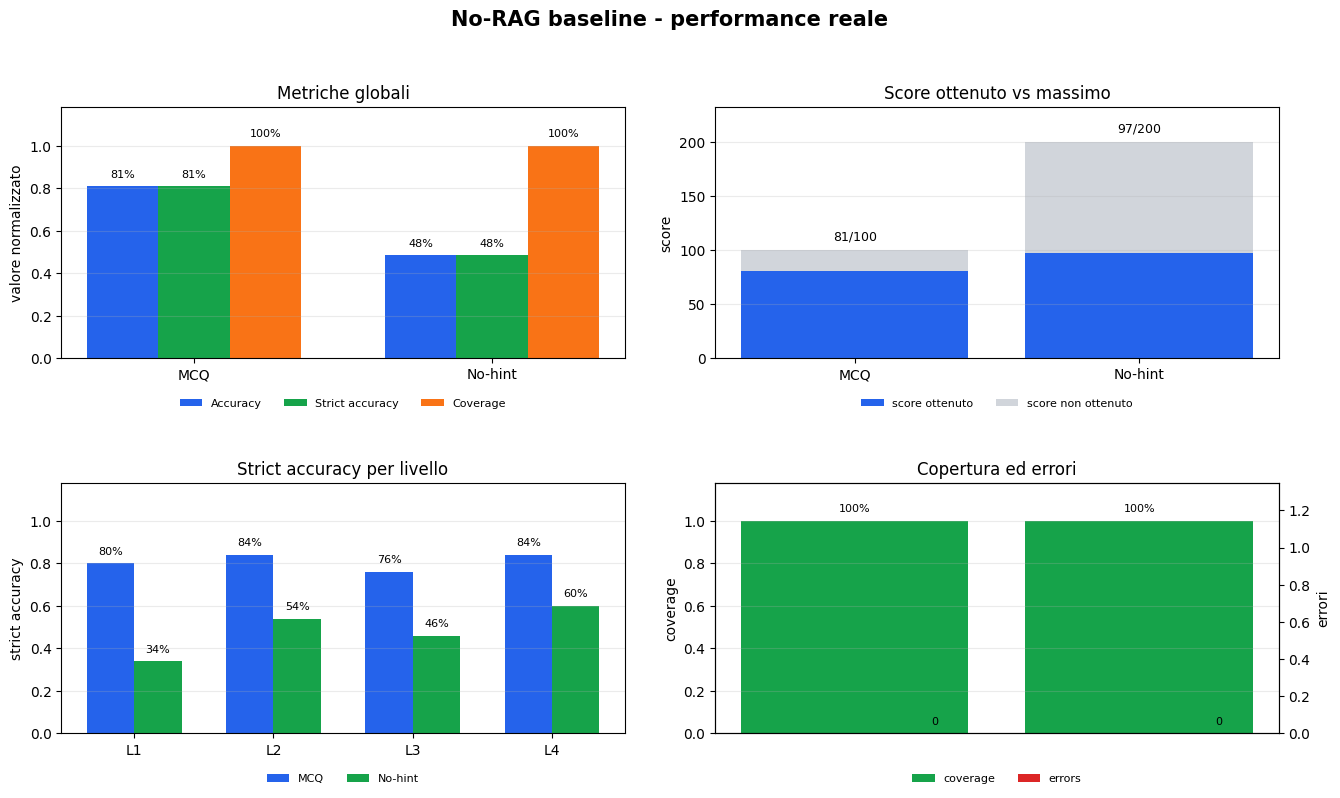

In [16]:
def _pct(value: float | None) -> float:
    return 0.0 if value is None else float(value)


def _add_percent_labels(ax, bars) -> None:
    for bar in bars:
        height = float(bar.get_height())
        ax.annotate(
            f"{height:.0%}",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 5),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=8,
        )


def _add_count_labels(ax, bars) -> None:
    for bar in bars:
        height = float(bar.get_height())
        ax.annotate(
            f"{height:.0f}",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 5),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=8,
        )


def plot_no_rag_summary(summary_data: dict[str, Any], title: str) -> None:
    datasets = ["mcq", "no_hint"]
    dataset_labels = ["MCQ", "No-hint"]
    blue = "#2563eb"
    green = "#16a34a"
    orange = "#f97316"
    gray = "#d1d5db"
    red = "#dc2626"

    fig, axes = plt.subplots(2, 2, figsize=(13.5, 8.5))
    fig.suptitle(title, fontsize=15, fontweight="bold")

    # 1) Normalized quality metrics.
    ax = axes[0, 0]
    metrics = [
        ("accuracy", "Accuracy", blue),
        ("strict_accuracy", "Strict accuracy", green),
        ("coverage", "Coverage", orange),
    ]
    x = list(range(len(datasets)))
    width = 0.24
    for offset, (metric, label, color) in enumerate(metrics):
        values = [_pct(summary_data[name][metric]) for name in datasets]
        bars = ax.bar(
            [idx + (offset - 1) * width for idx in x],
            values,
            width=width,
            label=label,
            color=color,
        )
        _add_percent_labels(ax, bars)
    ax.set_xticks(x, dataset_labels)
    ax.set_ylim(0, 1.18)
    ax.set_ylabel("valore normalizzato")
    ax.set_title("Metriche globali")
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3, fontsize=8, frameon=False)
    ax.grid(axis="y", alpha=0.25)

    # 2) Score obtained vs theoretical maximum.
    ax = axes[0, 1]
    score_values = [summary_data[name]["score_sum"] for name in datasets]
    max_values = [summary_data[name]["max_score_sum"] for name in datasets]
    missing_values = [max(maximum - score, 0) for score, maximum in zip(score_values, max_values)]
    bars_score = ax.bar(dataset_labels, score_values, label="score ottenuto", color=blue)
    ax.bar(dataset_labels, missing_values, bottom=score_values, label="score non ottenuto", color=gray)
    for bar, score, maximum in zip(bars_score, score_values, max_values):
        top = float(maximum)
        ax.annotate(
            f"{score}/{maximum}",
            xy=(bar.get_x() + bar.get_width() / 2, top),
            xytext=(0, 5),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
        )
    ax.set_ylim(0, max(max_values or [1]) * 1.16)
    ax.set_ylabel("score")
    ax.set_title("Score ottenuto vs massimo")
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2, fontsize=8, frameon=False)
    ax.grid(axis="y", alpha=0.25)

    # 3) Strict accuracy by difficulty level.
    ax = axes[1, 0]
    levels = sorted(set(summary_data["mcq"]["by_level"]) | set(summary_data["no_hint"]["by_level"]))
    x = list(range(len(levels)))
    width = 0.34
    mcq_values = [_pct(summary_data["mcq"]["by_level"].get(level, {}).get("strict_accuracy")) for level in levels]
    no_hint_values = [_pct(summary_data["no_hint"]["by_level"].get(level, {}).get("strict_accuracy")) for level in levels]
    bars_mcq = ax.bar([idx - width / 2 for idx in x], mcq_values, width=width, label="MCQ", color=blue)
    bars_no_hint = ax.bar([idx + width / 2 for idx in x], no_hint_values, width=width, label="No-hint", color=green)
    _add_percent_labels(ax, bars_mcq)
    _add_percent_labels(ax, bars_no_hint)
    ax.set_xticks(x, levels)
    ax.set_ylim(0, 1.18)
    ax.set_ylabel("strict accuracy")
    ax.set_title("Strict accuracy per livello")
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2, fontsize=8, frameon=False)
    ax.grid(axis="y", alpha=0.25)

    # 4) Coverage rate and error count use different axes to avoid mixed units.
    ax = axes[1, 1]
    coverage_values = [_pct(summary_data[name]["coverage"]) for name in datasets]
    bars_cov = ax.bar(dataset_labels, coverage_values, color=green, label="coverage")
    _add_percent_labels(ax, bars_cov)
    ax.set_ylim(0, 1.18)
    ax.set_ylabel("coverage")
    ax.set_title("Copertura ed errori")
    ax.grid(axis="y", alpha=0.25)

    ax_errors = ax.twinx()
    error_positions = [idx + 0.28 for idx in range(len(datasets))]
    error_values = [summary_data[name]["errors"] for name in datasets]
    bars_err = ax_errors.bar(error_positions, error_values, width=0.22, color=red, label="errors")
    _add_count_labels(ax_errors, bars_err)
    max_errors = max(error_values or [0])
    ax_errors.set_ylim(0, max(1, max_errors) * 1.35)
    ax_errors.set_ylabel("errori")
    ax_errors.set_xticks([])

    handles_left, labels_left = ax.get_legend_handles_labels()
    handles_right, labels_right = ax_errors.get_legend_handles_labels()
    ax.legend(
        handles_left + handles_right,
        labels_left + labels_right,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.12),
        ncol=2,
        fontsize=8,
        frameon=False,
    )

    fig.tight_layout(rect=(0, 0.04, 1, 0.95), h_pad=3.0, w_pad=2.5)
    show_plot(fig)


chart_summary = globals().get("real_summary", summary)
chart_title = "No-RAG baseline - performance reale" if "real_summary" in globals() else "No-RAG baseline - demo simulata"
plot_no_rag_summary(chart_summary, chart_title)


## Ispezione di una run esistente

Se il baseline reale è già stato eseguito, questa cella rilegge il summary e lo rende disponibile per confronti successivi.

In [14]:
run_dir = ROOT / "data" / "baseline_runs" / "no_rag"
summary_path = run_dir / "no_rag_summary.json"

if summary_path.exists():
    real_summary = json.loads(summary_path.read_text(encoding="utf-8"))
    print(json.dumps(real_summary, ensure_ascii=False, indent=2))
else:
    print(f"No full run found at {summary_path}")

{
  "mcq": {
    "accuracy": 0.81,
    "by_level": {
      "L1": {
        "accuracy": 0.8,
        "coverage": 1.0,
        "errors": 0,
        "judged": 25,
        "max_score_sum": 25,
        "mean_score": 0.8,
        "processed": 25,
        "score_sum": 20,
        "strict_accuracy": 0.8
      },
      "L2": {
        "accuracy": 0.84,
        "coverage": 1.0,
        "errors": 0,
        "judged": 25,
        "max_score_sum": 25,
        "mean_score": 0.84,
        "processed": 25,
        "score_sum": 21,
        "strict_accuracy": 0.84
      },
      "L3": {
        "accuracy": 0.76,
        "coverage": 1.0,
        "errors": 0,
        "judged": 25,
        "max_score_sum": 25,
        "mean_score": 0.76,
        "processed": 25,
        "score_sum": 19,
        "strict_accuracy": 0.76
      },
      "L4": {
        "accuracy": 0.84,
        "coverage": 1.0,
        "errors": 0,
        "judged": 25,
        "max_score_sum": 25,
        "mean_score": 0.84,
        "processe

## Lettura metodologica

La run no-RAG non prova la qualità del retrieval: isola il comportamento del modello senza contesto. Il valore sperimentale sta nel confronto successivo: se uno step RAG migliora accuracy, coverage o strict accuracy rispetto a questo baseline, il miglioramento è attribuibile alla pipeline di recupero e grounding, non alla sola capacità del modello.